In [26]:
import sys
print(sys.executable)

/home/pyodide/this.program


In [27]:
%pip install seaborn

In [28]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [30]:
df = pd.read_csv("Retail_sales.csv")

df.head()

,Date,Customer_ID,Age,Gender,Product_Name,Category,Quantity,Sales
0,2025-04-10,C1001,48,Female,T-Shirt,Clothing,8,303.10
1,2025-01-05,C1002,52,Male,Jacket,Clothing,4,179.52
2,2025-03-06,C1003,18,Male,Headphones,Electronics,7,1571.16
3,2025-05-16,C1004,47,Female,Chair,Furniture,8,1099.03
4,2025-02-06,C1005,20,Male,Jeans,Clothing,8,359.25


In [31]:
df.shape

(50, 8)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          50 non-null     str    
 1   Customer_ID   50 non-null     str    
 2   Age           50 non-null     int64  
 3   Gender        50 non-null     str    
 4   Product_Name  50 non-null     str    
 5   Category      50 non-null     str    
 6   Quantity      50 non-null     int64  
 7   Sales         50 non-null     float64
dtypes: float64(1), int64(2), str(5)
memory usage: 2.2 KB


In [33]:
df.isnull().sum()

Date            0
Customer_ID     0
Age             0
Gender          0
Product_Name    0
Category        0
Quantity        0
Sales           0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.drop_duplicates(inplace=True)

In [37]:
df['Date']=pd.to_datetime(df['Date'])

In [38]:
df.describe()

,Date,Age,Quantity,Sales
count,50,50.000000,50.000000,50.000000
mean,2025-06-09 17:16:48,37.520000,4.340000,446.139200
min,2025-01-05 00:00:00,18.000000,1.000000,22.850000
25%,2025-03-06 00:00:00,26.000000,2.250000,142.067500
50%,2025-06-05 12:00:00,38.500000,4.000000,274.910000
75%,2025-09-03 00:00:00,47.000000,6.000000,537.310000
max,2025-12-25 00:00:00,63.000000,8.000000,1683.780000
std,NaN,13.123029,2.255243,449.061961


In [39]:
df.mean(numeric_only=True)

Age          37.5200
Quantity      4.3400
Sales       446.1392
dtype: float64

In [40]:
df.median(numeric_only=True)

Age          38.50
Quantity      4.00
Sales       274.91
dtype: float64

In [41]:
df.mode().iloc[0]

Date            2025-02-13 00:00:00
Customer_ID                   C1001
Age                            47.0
Gender                         Male
Product_Name                  Chair
Category                   Clothing
Quantity                        4.0
Sales                         22.85
Name: 0, dtype: object

In [42]:
df.std(numeric_only=True)

Age          13.123029
Quantity      2.255243
Sales       449.061961
dtype: float64

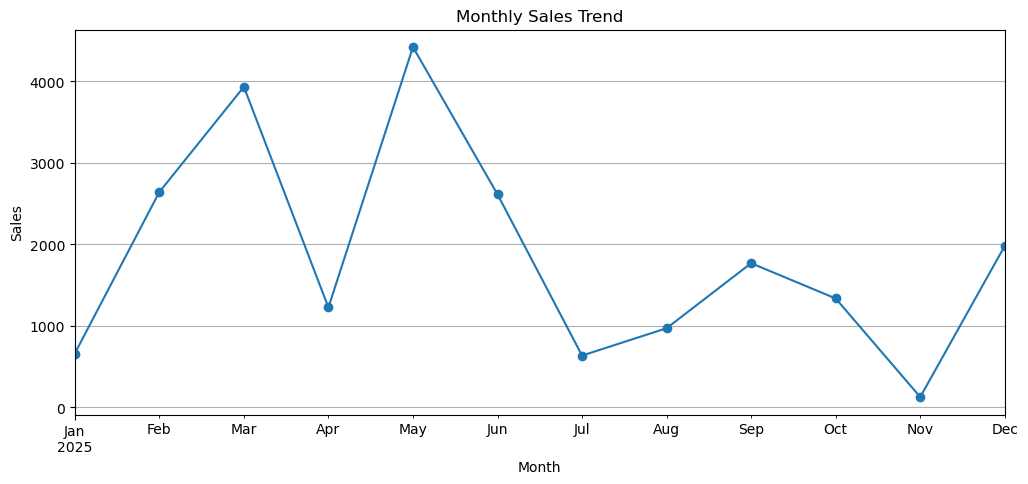

In [43]:
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

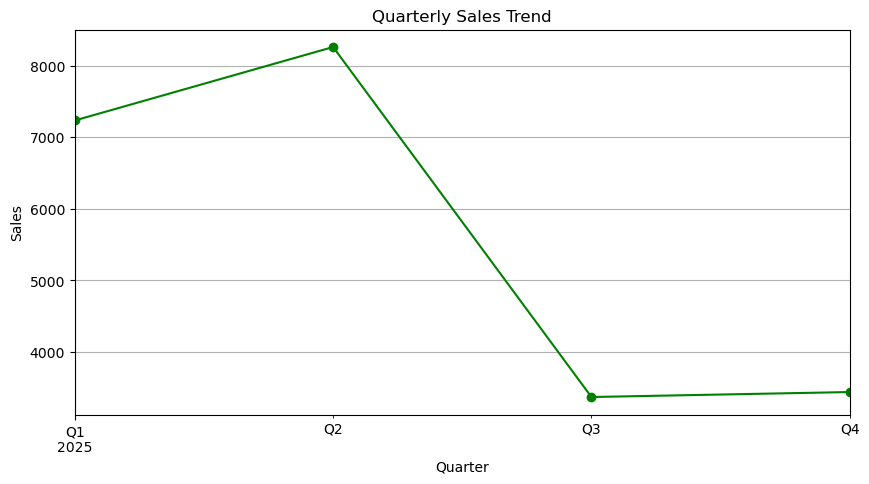

In [44]:
quarterly_sales = df.groupby(
    df['Date'].dt.to_period('Q')
)['Sales'].sum()

plt.figure(figsize=(10,5))

quarterly_sales.plot(
    marker='o',
    color='green'
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

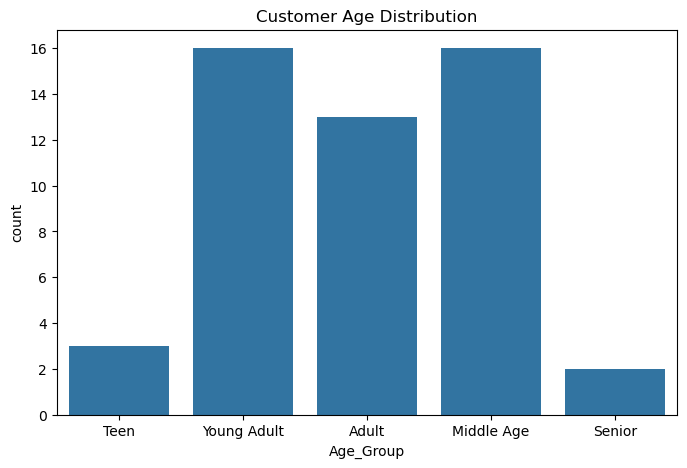

In [45]:
bins=[0,18,30,45,60,100]

labels=[
"Teen",
"Young Adult",
"Adult",
"Middle Age",
"Senior"
]

df['Age_Group']=pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Age_Group'
)

plt.title("Customer Age Distribution")

plt.show()

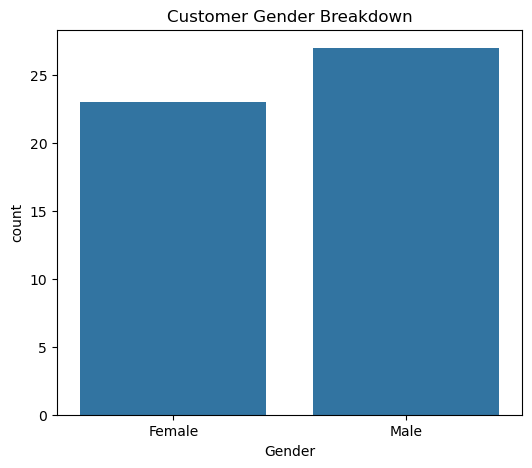

In [46]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title("Customer Gender Breakdown")

plt.show()

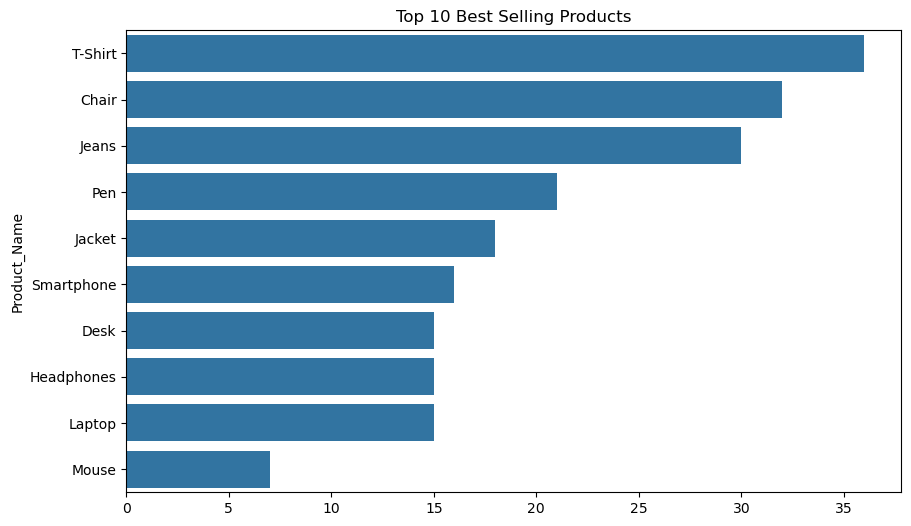

In [47]:
top_products = (
df.groupby('Product_Name')['Quantity']
.sum()
.sort_values(
ascending=False
)
.head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
x=top_products.values,
y=top_products.index
)

plt.title(
"Top 10 Best Selling Products"
)

plt.show()

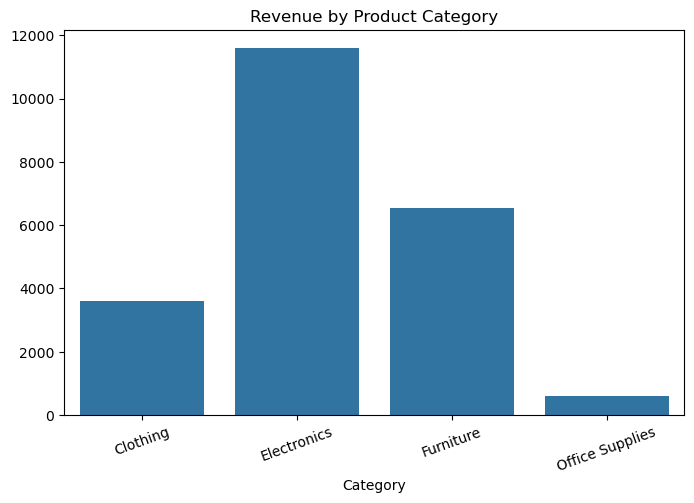

In [48]:
category_sales = (
df.groupby('Category')['Sales']
.sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
x=category_sales.index,
y=category_sales.values
)

plt.title(
"Revenue by Product Category"
)

plt.xticks(rotation=20)

plt.show()

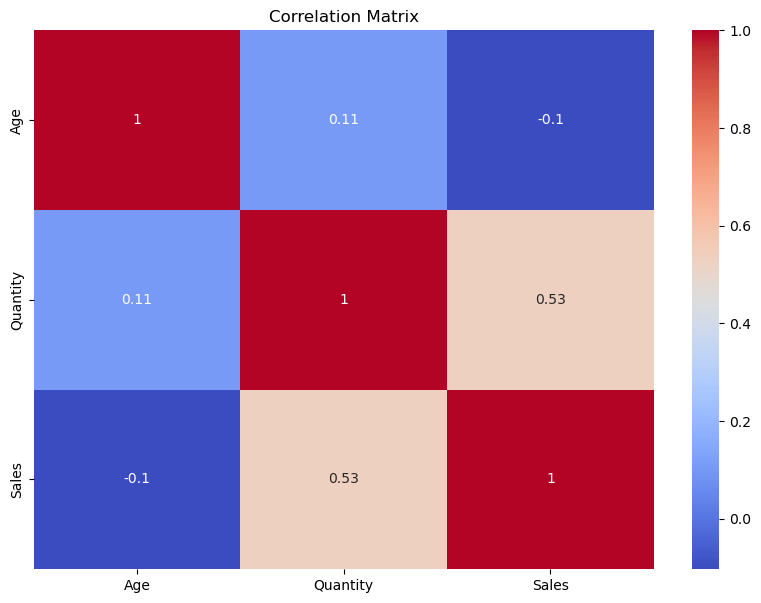

In [49]:
plt.figure(figsize=(10,7))

sns.heatmap(
df.select_dtypes(
include='number'
).corr(),
annot=True,
cmap="coolwarm"
)

plt.title(
"Correlation Matrix"
)

plt.show()

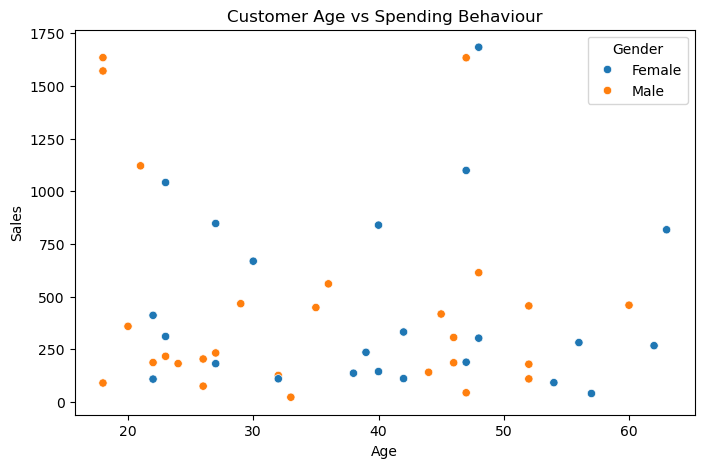

In [50]:
plt.figure(figsize=(8,5))

sns.scatterplot(
data=df,
x="Age",
y="Sales",
hue="Gender"
)

plt.title(
"Customer Age vs Spending Behaviour"
)

plt.show()